In [1]:
import numpy as np
import healpy as hp
import sys
import argparse
sys.path.append('/global/homes/l/lonappan/workspace/cobi')
from cobi import mpi
from cobi.simulation import LATskyC, SATskyC
from cobi.spectra import SpectraCross
from cobi.calibration import Sat4LatCross, Sat4LatCross_FGFit

In [19]:
from cobi.config import load_config

config_file = "../jobs/iso/config/b0p3_baseline_C1_gc90_d1s1.yaml"
config = load_config(config_file)


In [20]:
lat = LATskyC(config["libdir"], config["nside"], config["cb_model"], config["beta"],
              alpha=config["alpha_lat"], alpha_err=config["alpha_lat_err"],
              dust_model=config["dust_model"], sync_model=config["sync_model"],
              bandpass=config["lat_bandpass"], verbose=config["verbose"],
              nsplits=config["nsplits"], noise_model=config["noise_model"],
              noise_sensitivity=config["noise_sensitivity"])

sat = SATskyC(config["libdir"], config["nside"], config["cb_model"], config["beta"],
              alpha=config["alpha_sat"], alpha_err=config["alpha_sat_err"],
              dust_model=config["dust_model"], sync_model=config["sync_model"],
              bandpass=config["sat_bandpass"], verbose=config["verbose"],
              nsplits=config["nsplits"], noise_model=config["noise_model"],
              noise_sensitivity=config["noise_sensitivity"])

spec = SpectraCross(config["libdir"], lat, sat,
                    binwidth=config["binwidth"], galcut=config["galcut"],
                    aposcale=config["aposcale"])

CMB : INFO - Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected


Noise : INFO - Noise Model: sensitivity mode 'baseline'.
Noise : INFO - Noise Model:[LAT] White + 1/f noise v3.1.1
CMB : INFO - Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
/pscratch/sd/l/lonappan/software_pkgs/cb/lib/python3.10/site-packages/so_models_v3/SO_Noise_Calculator_Public_v3_1_2.py:219: RuntimeWarning: divide by zero encountered in scalar divide
  cov_weight[i,j] += ( tube_count * N_tels /
Noise : INFO - Noise Model: sensitivity mode 'baseline'.
Noise : INFO - Noise Model:[SAT] White + 1/f noise v3.1.1


In [21]:
eb = spec.data_matrix(0,which='EB')

In [7]:
import matplotlib.pyplot as plt

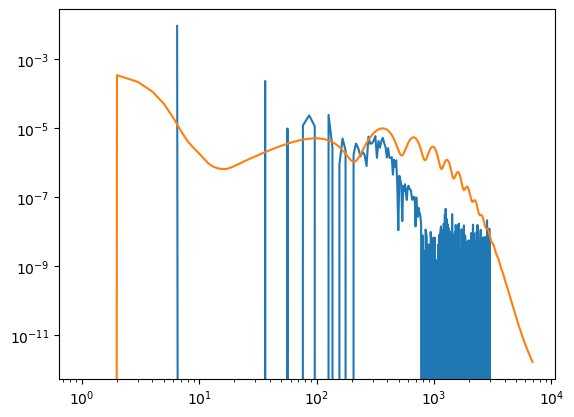

In [26]:
plt.loglog(spec.binInfo.get_effective_ells(),eb[-3,-1])
plt.loglog(lat.cmb.get_cb_lensed_spectra(0.3,dl=False)['eb'])

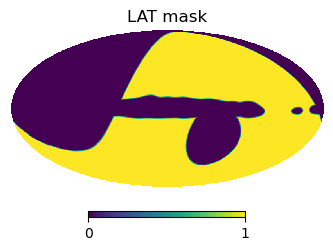

In [6]:
hp.mollview(spec.get_mask('LAT'),sub=(1,2,1), title='LAT mask')

In [6]:
# for idx in range(100):
#     lat.SaveObsQUs(idx)
#     sat.SaveObsQUs(idx)
#     spec.__spectra_matrix_core__(idx, which='EB')
#     print(f"Done with {idx}")


In [15]:
lh_angle = Sat4LatCross(spec, sat_err=config["alpha_sat_err"], beta_fid=config["beta"],
                            sat_lrange=(30, lmax), lat_lrange=(100, 3000),
                            fit_per_split=False, spectra_selection='all', num_sims=100,
                            verbose=False,cov_mode='diagonal')

CMB : INFO - Loading CMB power spectra from file
INFO:CMB:Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
INFO:CMB:Isotropic(constant) cosmic birefringence model selected


In [16]:
lh_angle.__pnames__

['a_LAT_93', 'a_LAT_145', 'a_SAT_93', 'a_SAT_145', 'beta']

CMB : INFO - Loading CMB power spectra from file
INFO:CMB:Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
INFO:CMB:Isotropic(constant) cosmic birefringence model selected
100%|██████████| 4000/4000 [07:55<00:00,  8.42it/s]


Removed no burn in


CMB : INFO - Loading CMB power spectra from file
INFO:CMB:Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
INFO:CMB:Isotropic(constant) cosmic birefringence model selected


Done with lmax=50


100%|██████████| 4000/4000 [09:49<00:00,  6.79it/s] 


...

Done with lmax=200


100%|██████████| 4000/4000 [10:31<00:00,  6.33it/s]  


Removed no burn in


CMB : INFO - Loading CMB power spectra from file
INFO:CMB:Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
INFO:CMB:Isotropic(constant) cosmic birefringence model selected


Done with lmax=250
Removed no burn in
Done with lmax=300


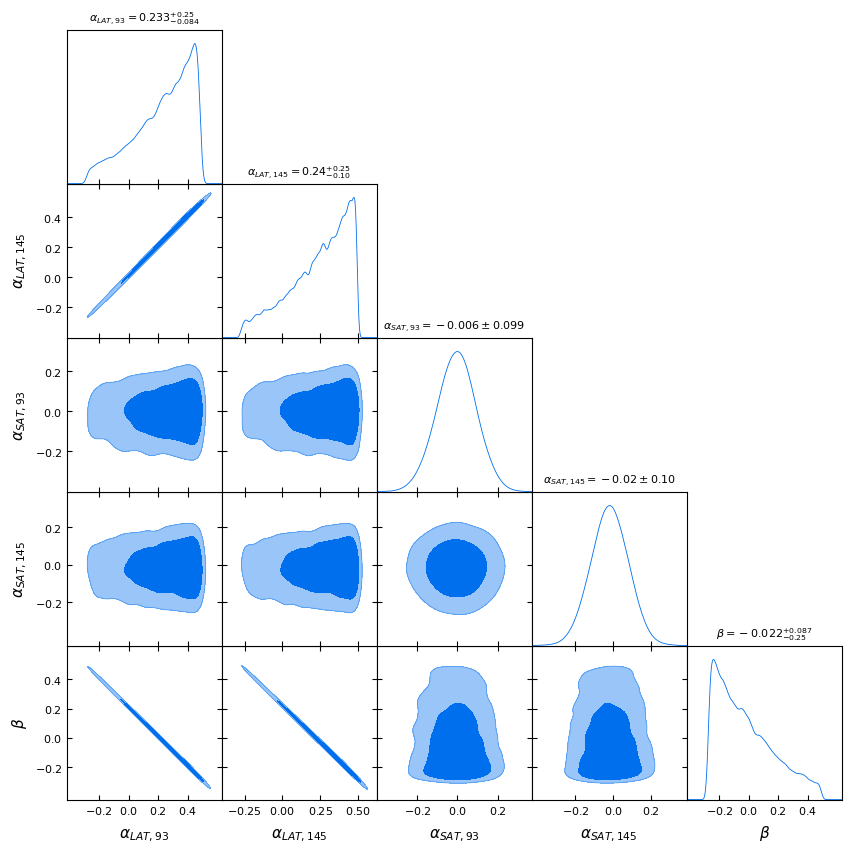

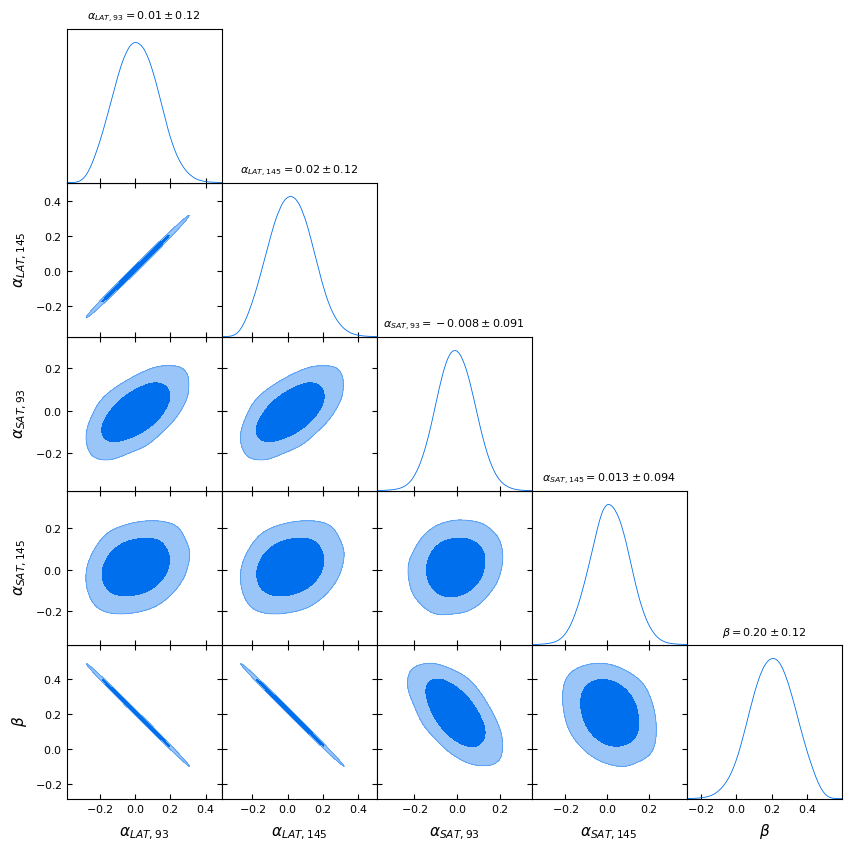

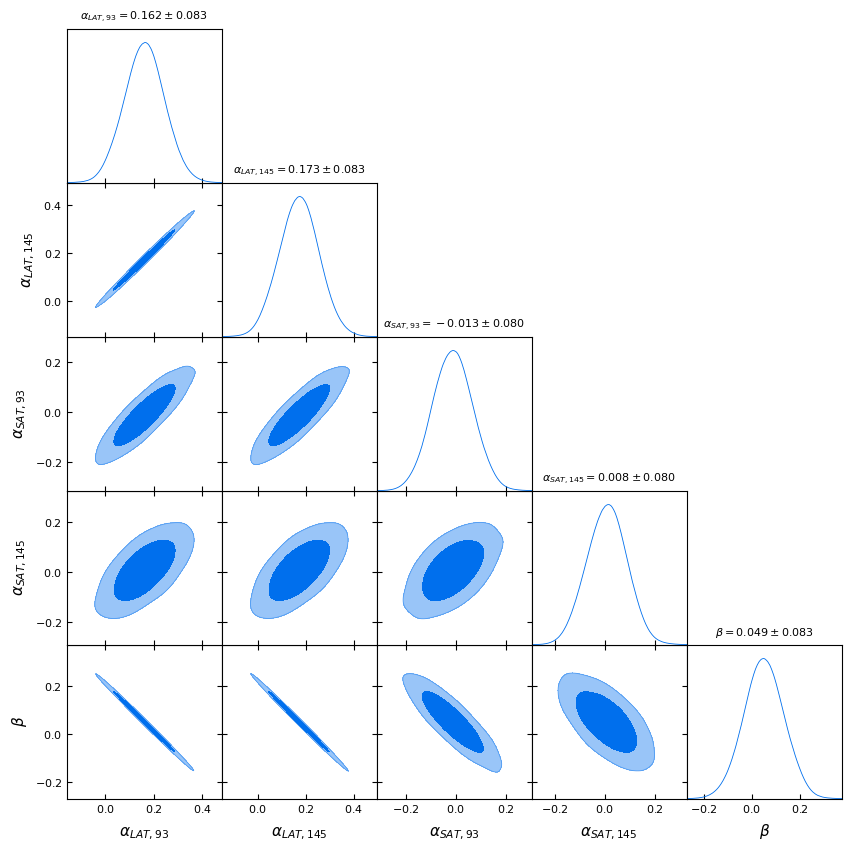

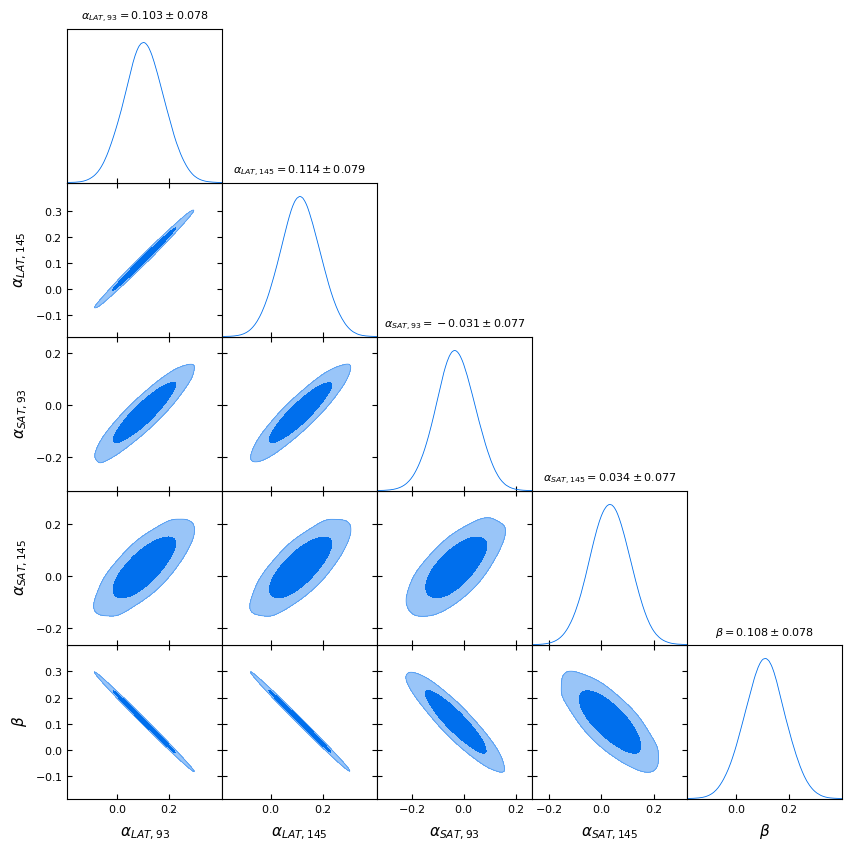

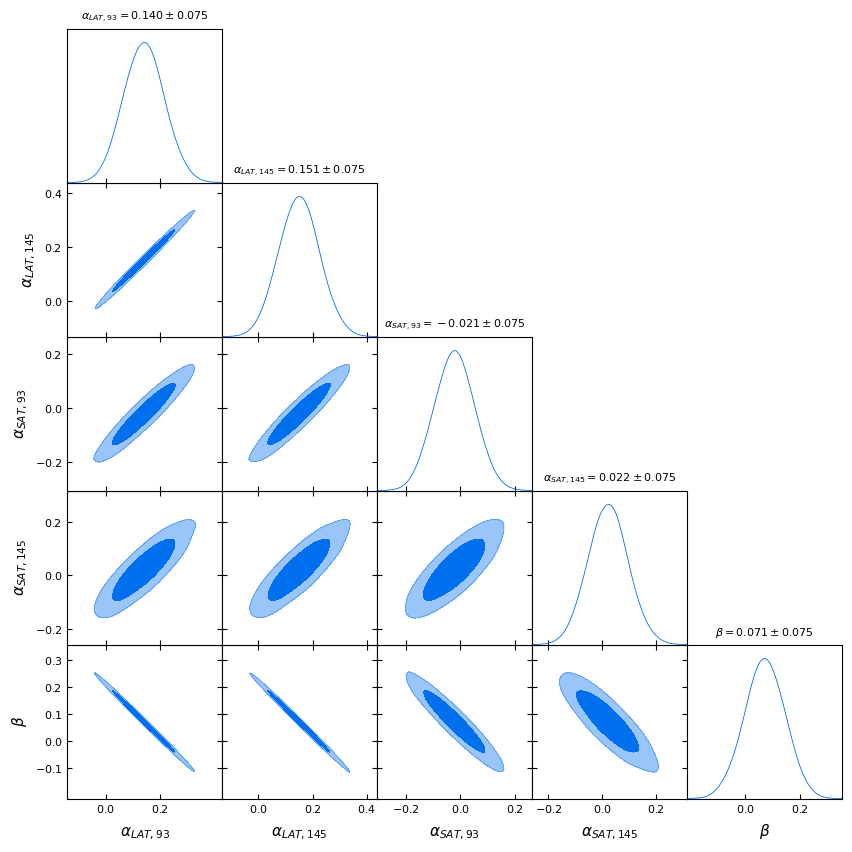

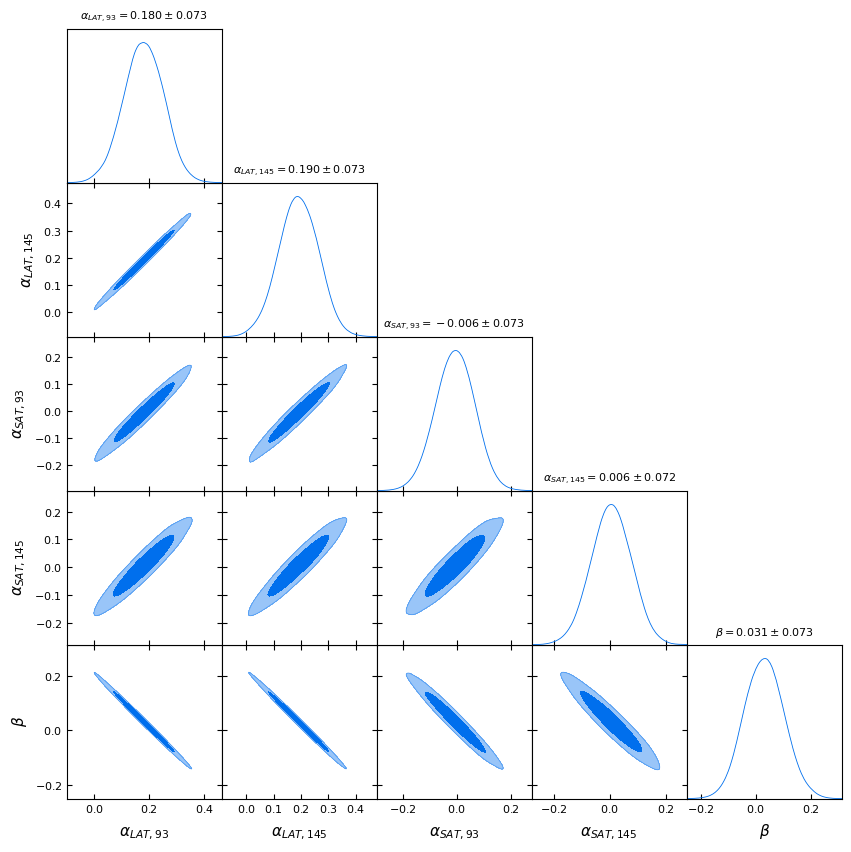

In [8]:
lmaxs = [50, 100, 150, 200, 250, 300]
for lmax in lmaxs:
    lh_angle = Sat4LatCross(spec, sat_err=config["alpha_sat_err"], beta_fid=config["beta"],
                            sat_lrange=(30, lmax), lat_lrange=(100, 3000),
                            fit_per_split=False, spectra_selection='all', num_sims=100,
                            verbose=False,cov_mode='diagonal')
    lh_angle.plot_posteriors(64,4000, fiducial_params=[0.2,0.2, 0.0,0.0, 0.3],burnin=400)
    print(f"Done with lmax={lmax}")

In [6]:
lh_angle.plot_posteriors(64,4000, fiducial_params=[0.2,0.2, 0.0,0.0, 0.3],burnin=400)

  2%|▏         | 62/4000 [00:07<08:13,  7.99it/s]Traceback (most recent call last):
  File "/pscratch/sd/l/lonappan/software_pkgs/cb/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/global/homes/l/lonappan/workspace/cobi/cobi/calibration.py", line 428, in ln_prob
    return -np.inf if not np.isfinite(lp) else lp + self.ln_likelihood(theta)
  File "/global/homes/l/lonappan/workspace/cobi/cobi/calibration.py", line 419, in ln_likelihood
    chisq_val = self.chisq(theta)
  File "/global/homes/l/lonappan/workspace/cobi/cobi/calibration.py", line 407, in chisq
    model = self.theory(theta)
  File "/global/homes/l/lonappan/workspace/cobi/cobi/calibration.py", line 806, in theory
    model[i, j] = self.binner.bin_cell(term)
  File "/pscratch/sd/l/lonappan/software_pkgs/cb/lib/python3.10/site-packages/pymaster/bins.py", line 278, in bin_cell
    cl1d = lib.bin_cl(self.bin, cls_in, len(cls_in) * self.bin.n_bands)
  

emcee: Exception while calling your likelihood function:
  params: [0.06472775 0.03206517 0.03097128 0.0424267  0.1652096 ]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [17]:
lh_angle_fgfit = Sat4LatCross_FGFit(spec, sat_err=config["alpha_sat_err"], beta_fid=config["beta"],
                                    sat_lrange=(30, 300), lat_lrange=(100, 3000),
                                    fit_per_split=False, spectra_selection='all', num_sims=100,
                                    verbose=True,cov_mode='diagonal',fg_model='geometric')


INFO:Sat4LatCross_FGFit:Initializing Sat4LatCross_FGFit...
INFO:Sat4LatCross_FGFit:Loading cached mean/std spectra...
INFO:Sat4LatCross_FGFit:Initialized Sat4LatCross_FGFit.
CMB : INFO - Loading CMB power spectra from file
INFO:CMB:Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
INFO:CMB:Isotropic(constant) cosmic birefringence model selected
INFO:Sat4LatCross_FGFit:Loading cached foreground EB templates...


In [20]:
lh_angle_fgfit.__plabels__

['\\alpha_{LAT,93}',
 '\\alpha_{LAT,145}',
 '\\alpha_{SAT,93}',
 '\\alpha_{SAT,145}',
 '\\beta',
 'A_{fg,145}',
 'A_{fg,93}']

100%|██████████| 4000/4000 [08:50<00:00,  7.54it/s]


Removed no burn in


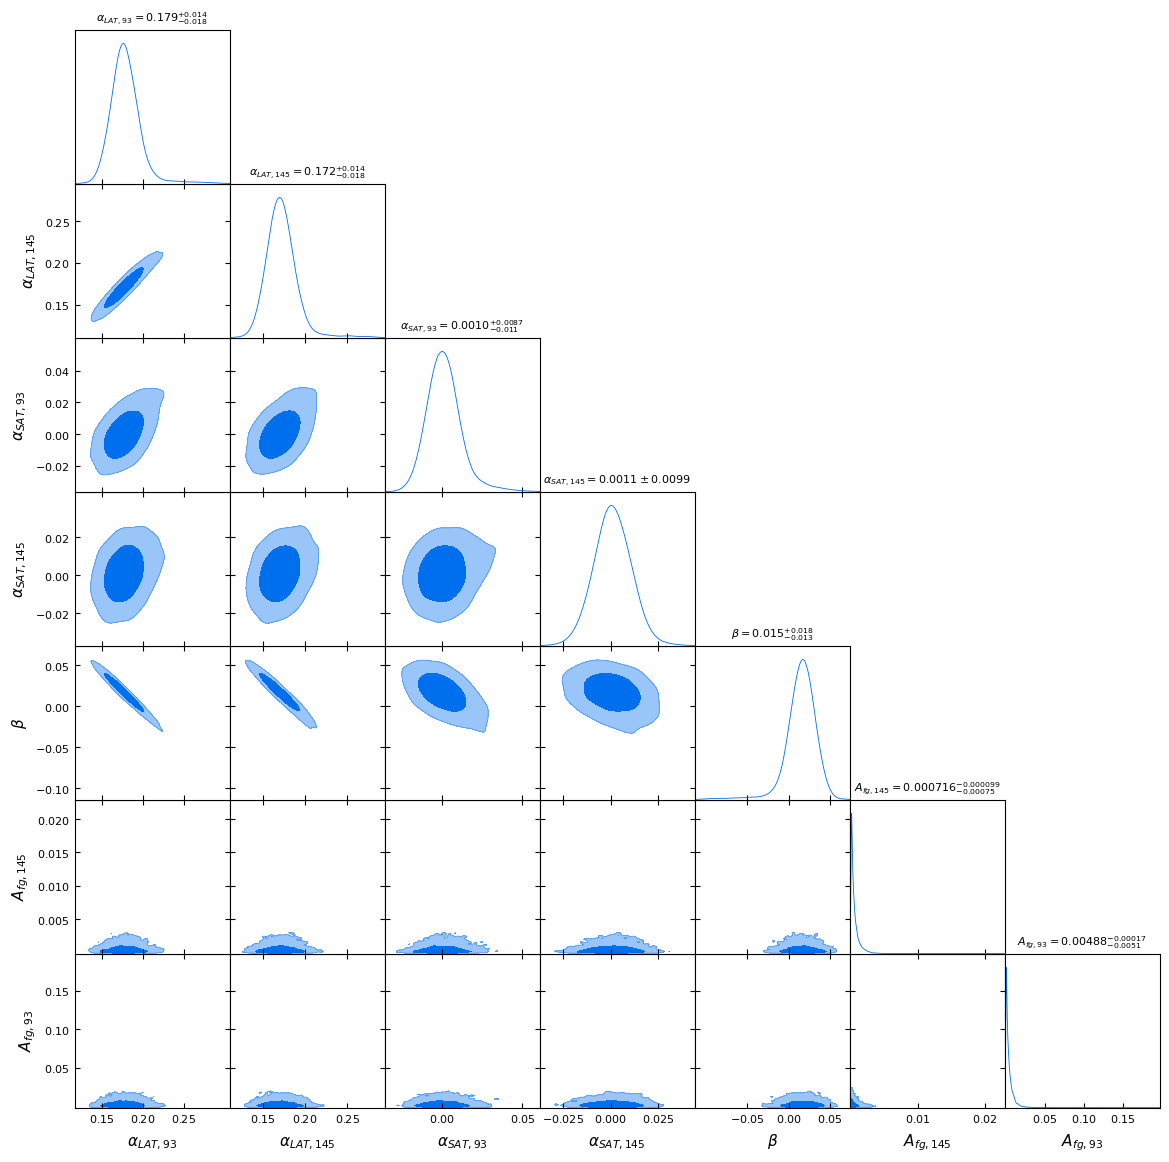

In [10]:
lh_angle_fgfit.plot_posteriors(64,4000, fiducial_params=[0.2,0.2, 0.0,0.0, 0.3, 0.5,0.5, ],burnin=200)